# Abstract

The purpose of this notebook is to allow users to become familiar with model fitting in a Google colaboratory (colab) environment using Jupyter notebooks. The programming code is R, not Python. For additional resources:

*   [Introduction to Google Colab](https://www.tutorialspoint.com/google_colab/index.htm), website
*   [Introduction to Jupyter Notebooks.ipynb](https://github.com/OpenActTextDev/ConstructPortfolio/blob/main/Notebooks/Introduction%20to%20Jupyter%20Notebooks.ipynb), Jupyter notebook available from the course Github repository (repo).


<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/OpenActTextDev/ConstructPortfolio/blob/main/Notebooks/InvestmentPortfolios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>





#  Getting Started

Start by going to "Runtime", select "Change Runtime Type", ensure that "R" is selected, and click "Save".

Next, run the following two boxes. The first checks that we can do basic calculations. The second is an "R" command (generate 10 standard normal random variates), to make sure that "R" is working. Then, try changing the numbers so you can convince yourself that this is an interactive environment.

In [1]:
1 + 7

[1] 8

In [2]:
rnorm(10)

[1] -0.87234535  0.87826026  1.64191418 -0.58255026 -0.02729073  0.78824135
 [7]  0.69355854 -0.82633026  0.17550456  0.67475839

You can make changes to a Colab notebook, and they will persist for as long as you keep your browser tab open. But once you close it, the changes will be lost. To avoid this, make sure you save a copy of the notebook to your Google Drive by selecting File → “Save a copy in Drive”.

## Load Libraries

As is the custom with Jupyter notebooks, we start by loading some libraries that are going to be helpful. In the following code, we also indicate where the libraries are needed with comments.

In [3]:
install.packages(c("xts", "PerformanceAnalytics"))
library(xts)
library(PerformanceAnalytics)
library(RColorBrewer)
#install.packages("alabama")
#library(alabama)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘zoo’, ‘quadprog’


Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric



Attaching package: ‘PerformanceAnalytics’


The following object is masked from ‘package:graphics’:

    legend




# Import and Describe the Data

First, we import the data from the book website. At the repo "https://github.com/OpenActTextDev/ActuarialRegression", you will see other datasets.

In [4]:
download.file("https://users.ssc.wisc.edu/~jfrees/InsurableRisks/DataDownload/InsuranceStockReturnData/InsurSectorReturns2023.RData", destfile = "InsurSectorReturns2023.RData")
load(file = "InsurSectorReturns2023.RData")

In [5]:
download.file("https://users.ssc.wisc.edu/~jfrees/InsurableRisks/DataDownload/InsuranceStockReturnData/InsurSectorPrices2023.RData", destfile = "InsurSectorPrices2023.RData")
load(file = "InsurSectorPrices2023.RData")

In [6]:
# For illustration only, not needed here
#Hexpend <- read.csv("https://raw.githubusercontent.com/OpenActTextDev/ActuarialRegression/refs/heads/main/CSVData/HealthExpend.csv", header=TRUE)

Just to make sure that data was read in properly, let's look at the structure and do a summary.

In [7]:
# List objects with details
ls.str()

mu :  Named num [1:8] 0.000987 0.000657 0.000825 0.000384 0.000631 ...
p.num :  int 8
prices : An xts object on 2015-01-05 / 2023-09-14 containing: 
  Data:    double [2265, 8]
  Columns: United Health, AIA, Ping An, Chubb, Allianz ... with 3 more columns
  Index:   Date [2265] (TZ: "UTC")
Return : An xts object on 2015-01-06 / 2023-09-14 containing: 
  Data:    double [2264, 8]
  Columns: United Health, AIA, Ping An, Chubb, Allianz ... with 3 more columns
  Index:   Date [2264] (TZ: "UTC")
Return_trn : An xts object on 2015-01-06 / 2019-12-31 containing: 
  Data:    double [1299, 8]
  Columns: United Health, AIA, Ping An, Chubb, Allianz ... with 3 more columns
  Index:   Date [1299] (TZ: "UTC")
Return_tst : An xts object on 2020-06-29 / 2023-05-31 containing: 
  Data:    double [762, 8]
  Columns: United Health, AIA, Ping An, Chubb, Allianz ... with 3 more columns
  Index:   Date [762] (TZ: "UTC")
Sigma :  num [1:8, 1:8] 1.80e-04 1.36e-05 2.42e-05 4.87e-05 3.87e-05 ...
T_trn :  int 12

Below is some code I used to make an attractive figure. To get started, you might try just doing the following:

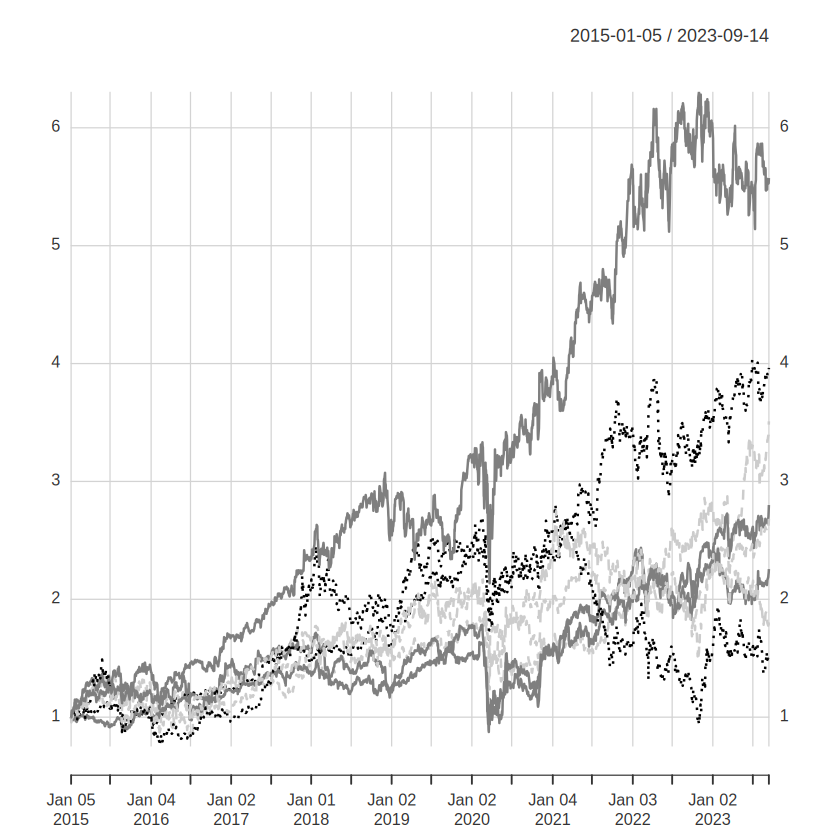

In [9]:
line_types <- c("solid", "dashed", "dotted","solid",
                "dashed", "dotted", "solid", "dashed")
grey_types <- c("grey50", "grey80","black", "grey50",
                "grey80","black", "grey50", "grey80")
mydata <- prices/rep(prices[1, ], each = nrow(prices))
 plot(mydata,   main = "", grid.col = "lightgray",
      col = grey_types, lty = line_types)

In [10]:
  FigRed    = "red"        ;  FigBlue   = "blue"
  FigGreen  = "green"      ;  FigLBlue  = "lightblue"
  FigDBlue  = "darkblue"   ;  FigDGreen = "darkgreen"
  FigLGreen = "lightgreen" ;  FigOrange = "orange"


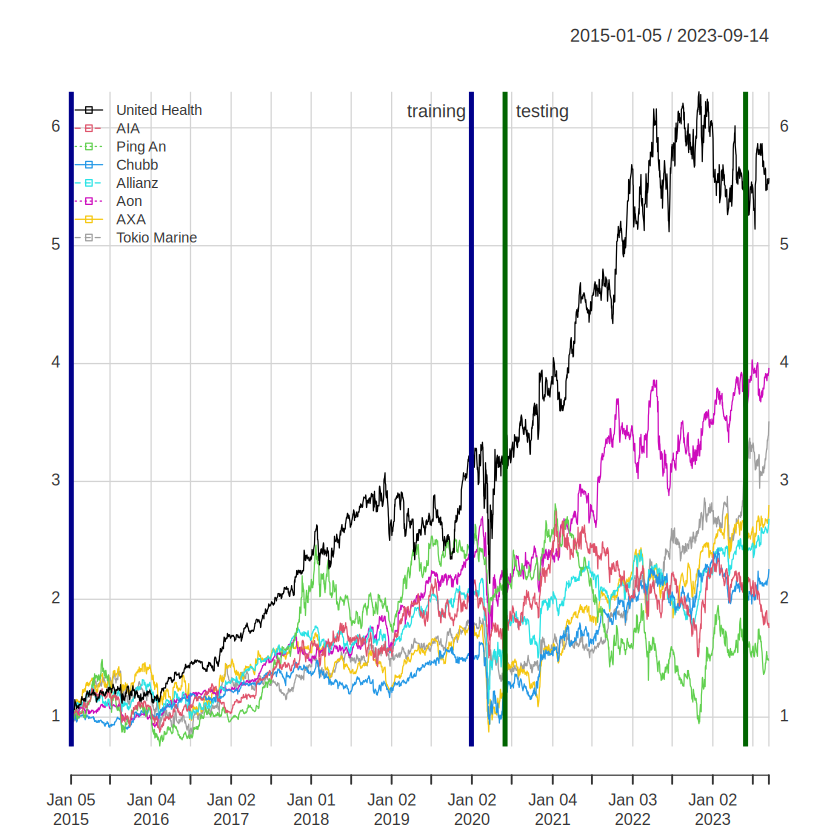

In [29]:
#  Plot Figure 1.1
#library(RColorBrewer)
{ plot(mydata,   main = "", grid.col = "lightgray", lwd = 1)
addLegend("topleft", pch=0, cex=0.8,lty = line_types)
addEventLines(xts("                      ",
                  index(Return["2015-01-06"])), srt=00,
                        pos=1, lwd = 4, col = FigDBlue)
addEventLines(xts("training              ",
                  index(Return["2019-12-31"])), srt=00,
                        pos=1, lwd = 4, col = FigDBlue)
addEventLines(xts("               testing",
                  index(Return["2020-06-01"])),  srt=0,
                        pos=1, lwd = 4, col = FigDGreen)
addEventLines(xts("",
                  index(Return["2023-05-31"])),  srt=0,
                        pos=1, lwd = 4, col = FigDGreen)
}

This is figure appears in the book (Section 1.3).

In [16]:
#  Create Table 1.4
temp1 <- t(table.AnnualizedReturns(Return_trn))
temp2 <- t(table.AnnualizedReturns(Return_tst))
RetSumm <- cbind(as.matrix(temp1), as.matrix(temp2))
colnames(RetSumm) <- c("Train Ann Return",    "Train Std Dev",
                       "Train Sharpe (Rf=0)", "Test Ann Return",
                       "Test Std Dev", "Test Sharpe (Rf=0)" )
RetSumm


,Train Ann Return,Train Std Dev,Train Sharpe (Rf=0),Test Ann Return,Test Std Dev,Test Sharpe (Rf=0)
United Health,0.2538,0.2127,1.1929,0.2065,0.2202,0.9377
AIA,0.1468,0.2394,0.6133,0.0219,0.3112,0.0705
Ping An,0.1888,0.2643,0.7142,-0.1080,0.3770,-0.2864
Chubb,0.0875,0.1604,0.5458,0.1623,0.2374,0.6837
Allianz,0.1505,0.1932,0.7790,0.0918,0.2280,0.4026
Aon,0.1817,0.1695,1.0721,0.1827,0.2354,0.7763
AXA,0.1155,0.2406,0.4800,0.2113,0.2451,0.8620
Tokio Marine,0.1191,0.2666,0.4468,0.2951,0.2479,1.1903


#  Create Optimal Portfolio

We explore three ways to create optimal porfolios from data.
1.  The first is based on first principles, appealing because it is direct and interpretable but limited in the number of conditions one can imposed.
2.  The second is based on convex optimization (CVXR package in R), fast but will not be a good basis for nonlinear insurance problems.
3.  The third is a general optimization approach (Alabama package in R) that will be the general workhorse for this workshop.

##  First Principles

Mostly follow [Section 3.4.1](https://users.ssc.wisc.edu//~ewfrees/InsurableRisks/C3Balance.html#markowitz-portfolio-optimization) of the book for notation, but to simplify things, let us use $\boldsymbol{\mu} = (\mu_1 , \ldots, \mu_p)'$ to denote the vector of mean returns of $p$ asset risks.

The problem we wish to solve is

\begin{array}{lc}
{\small \text{minimize}}_{\mathbf{c}}  &  \mathbf{c}^{\prime} ~\boldsymbol \Sigma~\mathbf{c}  \\
{\small \text{subject to}} & \mathbf{c}^{\prime} ~\boldsymbol {\mu} \ge Req_0 \\
& \mathbf{c}^{\prime} \mathbf{1} = \sum_j c_j = 1 \\
\end{array}

From [Exercise 4.3](https://users.ssc.wisc.edu//~ewfrees/InsurableRisks/C4PortMgt.html#Sec:ExerMultRisks) (Note book typo!!!), the solution is

\begin{equation}
\mathbf{\hat{c}}  = LME_1 ~\boldsymbol \Sigma^{-1} \boldsymbol{\mu}  +LME_2 ~\boldsymbol \Sigma^{-1}  \mathbf{1} ,
\end{equation}
where
\begin{equation}
{\small
LME_1  =
\frac{Req_0 ~A_3-A_2}{A_1A_3-A_2^2}
\\
LME_2 =
\frac{Req_0 ~A_2-A_1}{A_2^2 - A_1A_3}
}
\end{equation}

and $A_1=\boldsymbol{\mu}^{\prime}\boldsymbol \Sigma^{-1} \boldsymbol{\mu}$, $A_2=\mathbf{1}^{\prime}\boldsymbol \Sigma^{-1} \boldsymbol{\mu}$, and $A_3=\mathbf{1}^{\prime}\boldsymbol \Sigma^{-1}  \mathbf{1}$.




To get this solution, start with the Lagrangian

$$
\begin{array}{ll}
LA &= \frac{1}{2}\mathrm{Var}[S(\mathbf{c})] + LME_1 (Req_0-\mathrm{E }[S(\mathbf{c})] )
 + LME_2 (1-\mathbf{c}^{\prime}\mathbf{1} )\\
&= \frac{1}{2}\mathbf{c}^{\prime} \boldsymbol \Sigma \mathbf{c} + LME_1 [ Req_0 - \mathbf{c}^{\prime} ~\mathrm{E}(\mathbf{R})]
 + LME_2 (1-\mathbf{c}^{\prime}\mathbf{1} ).
\end{array}
$$

Then, take derivatives, set equal to zero, and solve. See the book for details.

In [17]:
Return_trn <- Return[1:1299, ]
Return_tst <- Return[1427:2188, ]

T_trn <- nrow(Return_trn)
mu    <- colMeans(Return_trn, na.rm = TRUE)
Sigma <- cov(Return_trn, use = "pairwise.complete.obs")
mu
Sigma

United Health           AIA       Ping An         Chubb       Allianz 
 0.0009873843  0.0006572788  0.0008245425  0.0003841186  0.0006308757 
          Aon           AXA  Tokio Marine 
 0.0007197875  0.0005500046  0.0005867331

,United Health,AIA,Ping An,Chubb,Allianz,Aon,AXA,Tokio Marine
United Health,1.795765e-04,1.363671e-05,2.423988e-05,4.865209e-05,3.866127e-05,4.896457e-05,4.684142e-05,1.903061e-05
AIA,1.363671e-05,2.273786e-04,1.374354e-04,8.552993e-06,4.759570e-05,1.286492e-05,6.091271e-05,6.997320e-05
Ping An,2.423988e-05,1.374354e-04,2.771947e-04,1.590676e-05,5.633245e-05,2.538171e-05,7.129552e-05,7.947779e-05
Chubb,4.865209e-05,8.552993e-06,1.590676e-05,1.020987e-04,4.115207e-05,6.546891e-05,4.482035e-05,1.537556e-05
Allianz,3.866127e-05,4.759570e-05,5.633245e-05,4.115207e-05,1.481248e-04,4.161890e-05,1.483542e-04,5.201980e-05
Aon,4.896457e-05,1.286492e-05,2.538171e-05,6.546891e-05,4.161890e-05,1.139725e-04,4.922395e-05,1.803677e-05
AXA,4.684142e-05,6.091271e-05,7.129552e-05,4.482035e-05,1.483542e-04,4.922395e-05,2.297479e-04,7.153617e-05
Tokio Marine,1.903061e-05,6.997320e-05,7.947779e-05,1.537556e-05,5.201980e-05,1.803677e-05,7.153617e-05,2.820284e-04


In [18]:
Req0 = 0.5 * sum(mu)
Req0
A1 = t(mu) %*% solve(Sigma) %*% mu
ones.vec = rep(1, 8)
A2 = t(ones.vec) %*% solve(Sigma) %*% mu
A3 = t(ones.vec) %*% solve(Sigma) %*% ones.vec
LME1 = as.numeric((Req0 * A3 - A2) /  (A1 * A3 - A2 * A2 ) )
LME2 = as.numeric( (Req0 * A2 - A1) / (A2 * A2 - A1 * A3 ) )
chat = LME1 * solve(Sigma) %*% mu + LME2 * solve(Sigma) %*% ones.vec
chat
#  A couple of checks
sum(chat)
t(chat) %*% mu

[1] 0.002670362

United Health,2.0675826
AIA,-0.1148899
Ping An,0.6420361
Chubb,-3.6602915
Allianz,1.0622426
Aon,2.1371850
AXA,-1.0289780
Tokio Marine,-0.1048870


[1] 1

0.002670362


Nice and simple. Unfortunately, the optimal allocations sometimes are above one, sometimes below zero. It is possible to include constraints and still get analytical solutions (see Exercise 11.1) but much easier to go with numerical procedures for constrained optimization.

## Convex Optimization

We first need to install a package for convex optimization called `CVXR`. For doing this on my own machine, it is straightforward - similar to any other package. However, for Colab, we need to grab an older version to make things works. I used Gemini to help me get through this. It is not something that you will need to do on your own system. Sadly, it also takes a while (7 minutes or so). Get it started, and walk away to something else.

For example, read Section 3.4 of the book to get more background on the asset allocation problem.

In [19]:
system('sudo apt-get update && sudo apt-get install -y libgmp-dev libmpfr-dev')
install.packages("remotes",
  repos = "https://cloud.r-project.org" )

remotes::install_version(package = "CVXR",
  version = "1.0-15",repos = "https://cloud.r-project.org",
  upgrade = "never")
library(CVXR)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Installing 6 packages: gmp, RcppEigen, osqp, scs, ECOSolveR, Rmpfr

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘CVXR’


The following object is masked from ‘package:stats’:

    power




With the following code, we get the same result as based on first principles.

In [20]:
Req0 = 0.5 * sum(mu)
c.prop_cvxr <- Variable(nrow(Sigma)) # Rename to avoid conflict with R variable
prob   <- Problem(Minimize(quad_form(c.prop_cvxr, Sigma)),
                  constraints = list(
                   sum(c.prop_cvxr) == 1,
                  t(mu) %*% c.prop_cvxr >= Req0))
result <- suppressWarnings(solve(prob))
c.prop_cvxr <- as.vector(result$getValue(c.prop_cvxr))
names(c.prop_cvxr) <- colnames(Sigma)
c.prop_cvxr

United Health           AIA       Ping An         Chubb       Allianz 
    2.0675826    -0.1148899     0.6420361    -3.6602915     1.0622426 
          Aon           AXA  Tokio Marine 
    2.1371850    -1.0289780    -0.1048870

The following code shows how to include additional constraints. However, by making the budget constraint too large (e.g., at 50%), one eliminates the feasible region - no solution!

In [21]:
#Req0 = 0.5 * sum(mu)
Req0 = 0.1 * sum(mu)
c.prop_cvxr1 <- Variable(nrow(Sigma)) # Rename to avoid conflict with R variable
prob   <- Problem(Minimize(quad_form(c.prop_cvxr1, Sigma)),
                  constraints = list(
                   c.prop_cvxr1 >= 0,
                   c.prop_cvxr1 <= 1,
                   sum(c.prop_cvxr1) == 1,
                  t(mu) %*% c.prop_cvxr1 >= Req0))
result <- suppressWarnings(solve(prob))
c.prop_cvxr1 <- as.vector(result$getValue(c.prop_cvxr1))
#names(c.prop_cvxr1) <- colnames(Sigma)
c.prop_cvxr1

[1] 1.324491e-01 1.419771e-01 3.536339e-02 2.859876e-01 1.196411e-01
[6] 1.892100e-01 5.936015e-08 9.537174e-02

And here is the fancier code included in the book. But, we have already done the big ideas...


In [22]:
portolioMinVar <- function(Sigma) {
  c.prop <- Variable(nrow(Sigma))
  prob   <- Problem(Minimize(quad_form(c.prop, Sigma)),
                  constraints = list(c.prop >= 0, sum(c.prop) == 1))
  result <- suppressWarnings(solve(prob))
  c.prop <- as.vector(result$getValue(c.prop))
  names(c.prop) <- colnames(Sigma)
  return(c.prop)
}
portolioMarkowitz <- function(mu, Sigma, lmd = 10) {
  c.prop <- Variable(nrow(Sigma))
  prob   <- Problem(Maximize(t(mu) %*% c.prop -
                    lmd*quad_form(c.prop, Sigma)),
                    constraints = list(c.prop >= 0, sum(c.prop) == 1))
  result <- suppressWarnings(solve(prob))
  c.prop <- as.vector(result$getValue(c.prop))
  names(c.prop) <- colnames(Sigma)
  return(c.prop)
}
c_Markowitz <- portolioMarkowitz(mu, Sigma)
c_MinVar <- portolioMinVar(Sigma)
c_Equal <- rep(1/8,8)
c_all <- cbind("MinVar"      = c_MinVar,
               "Markowitz"   = c_Markowitz,
               "Equal"       = c_Equal)

# compute returns of all portfolios
ret_all     <- xts(Return     %*% c_all, index(Return    ))
ret_all_trn <- xts(Return_trn %*% c_all, index(Return_trn))
ret_all_tst <- xts(Return_tst %*% c_all, index(Return_tst))

temp1 <- t(table.AnnualizedReturns(Return_trn))
temp2 <- t(table.AnnualizedReturns(Return_tst))
RetSumm <- cbind(as.matrix(temp1), as.matrix(temp2))
colnames(RetSumm) <- c("Train Ann Return", "Train Std Dev",
                       "Train Sharpe (Rf=0)", "Test Ann Return",
                       "Test Std Dev", "Test Sharpe (Rf=0)")
Lambda.vec <- c(seq(from=0, to = 3, length.out = 5),
                seq(from=3.5, to = 12, length.out = 5),
                seq(from=12.5, to = 100, length.out = 5))
Portmu     <- rep(0,length(Lambda.vec)) -> Portstd
PortPerf   <- matrix(0,2,length(Lambda.vec))
for (iVec in 1:length(Lambda.vec)) {
   MarkPort        <- portolioMarkowitz(mu, Sigma, lmd = Lambda.vec[iVec])
   ret_MarkPort    <- xts(Return_trn %*% MarkPort, index(Return_trn))
   PortPerf[,iVec] <- t(table.AnnualizedReturns(ret_MarkPort)[1:2,1])
   }
temp1    <- t(table.AnnualizedReturns(ret_all_trn))
temp2    <- t(table.AnnualizedReturns(ret_all_tst))
PortSumm <- cbind(as.matrix(temp1), as.matrix(temp2))
PortSumm

,Annualized Return,Annualized Std Dev,Annualized Sharpe (Rf=0%),Annualized Return,Annualized Std Dev,Annualized Sharpe (Rf=0%)
MinVar,0.1639,0.1190,1.3775,0.1682,0.1428,1.1783
Markowitz,0.2033,0.1260,1.6137,0.1656,0.1428,1.1597
Equal,0.1731,0.1302,1.3295,0.1554,0.1422,1.0928


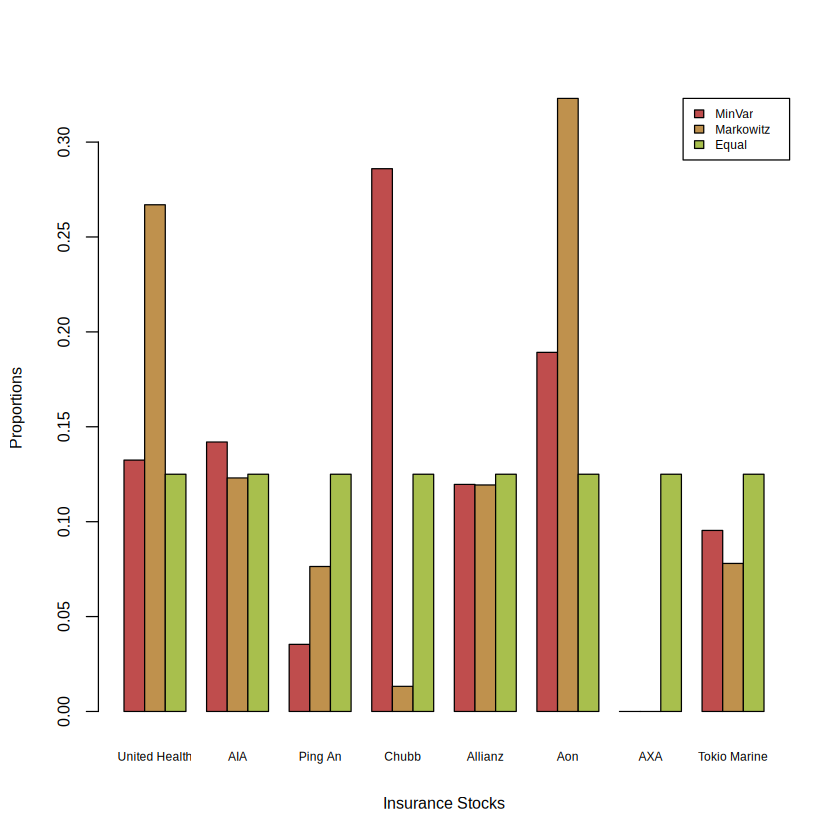

In [23]:
barplot(t(c_all), col = rainbow10equal[1:3], legend = colnames(c_all),
        cex=0.8, args.legend = list(x = "topright", ncol = 1, cex=0.6),
        cex.names=0.6, beside = TRUE, cex.lab=0.8, main = "",
        xlab = "Insurance Stocks", ylab = "Proportions")

## General Constrained Optimization Approach


In [30]:
install.packages("alabama")
library(alabama)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘numDeriv’


Loading required package: numDeriv


Attaching package: ‘numDeriv’


The following object is masked from ‘package:CVXR’:

    grad




### Optimization with `alabama::auglag`

We will use the `auglag` function for general constrained optimization. It requires:

*   An objective function (`fn`) to minimize.
    *   Optionally, a gradient function for `fn` (`gr`).
*   An inequality constraint function (`hin`) where `hin(x) >= 0`.
    *   Optionally, a gradient function for `hin` (`jac_hin`).
*   An equality constraint function (`heq`) where `heq(x) == 0`.
    *   Optionally, a gradient function for `heq` (`jac_heq`).

Our problem is:

*   **Minimize**: $ \mathbf{c}^{\prime} ~\boldsymbol \Sigma~\mathbf{c} $ (variance)
*   **Subject to**: $ \mathbf{c}^{\prime} ~\boldsymbol {\mu} \ge Req_0 $ (expected return)
*   **Subject to**: $ \mathbf{c}^{\prime} \mathbf{1} = 1 $ (sum of weights is 1)
*   **Subject to**: $ c_j \ge 0 $ for all $j$ (non-negative weights)

The following code gives the same as the CVXR code. Note that you need to provide starting values for this approach...

In [31]:
#Req0 = 0.5 * sum(mu)
Req0 = 0.1 * sum(mu)

# Objective function to minimize (variance)
eval_f <- function(c.prop_alabama) {
  return(t(c.prop_alabama) %*% Sigma %*% c.prop_alabama)
}

# Inequality constraints (hin >= 0)
# 1. c.prop_alabama >= 0
# 2. t(mu) %*% c.prop_alabama >= Req0
eval_g <- function(c.prop_alabama) {
  return(c(c.prop_alabama, t(mu) %*% c.prop_alabama - Req0))
}

# Equality constraint (heq == 0)
# sum(c.prop_alabama) == 1
eval_h <- function(c.prop_alabama) {
  return(sum(c.prop_alabama) - 1)
}

# Initial values for c.prop_alabama (equal weights)
c_init <- rep(1/nrow(Sigma), nrow(Sigma))

# Run the optimization
result_alabama <- auglag(
  par = c_init,
  fn = eval_f,
  hin = eval_g,
  heq = eval_h,
  control.outer=list(method="nlminb",trace=FALSE)
)

# Extract the optimal portfolio proportions
c.prop_alabama <- result_alabama$par
names(c.prop_alabama) <- colnames(Sigma)

print("Optimal portfolio proportions using `alabama::auglag`:")
round(c.prop_alabama, digits = 6)

print("Objective function value (variance) at optimum:")
print(eval_f(c.prop_alabama)) # Call the function to get the value

print("Check sum of proportions:")
print(sum(c.prop_alabama))

print("Check expected return constraint (should be >= Req0):")
print(t(mu) %*% c.prop_alabama)
print(paste("Required expected return (Req0):", Req0)) # Fixed line

[1] "Optimal portfolio proportions using `alabama::auglag`:"


United Health           AIA       Ping An         Chubb       Allianz 
     0.132440      0.142080      0.035185      0.286100      0.119677 
          Aon           AXA  Tokio Marine 
     0.189152      0.000000      0.095368

[1] "Objective function value (variance) at optimum:"
             [,1]
[1,] 5.619699e-05
[1] "Check sum of proportions:"
[1] 1
[1] "Check expected return constraint (should be >= Req0):"
             [,1]
[1,] 0.0006306679
[1] "Required expected return (Req0): 0.0005340724999839"


#  Download Your Own Data

Instead of using data I downloaded earlier, you can use the following code to download your own data and then re-run the prior code.

*  See if you can download more recent data.
*  If you have time and interest, try picking a few different investments.

## R Code to Extract Yahoo Returns

In [32]:
install.packages("quantmod")   # to download stock data
library(quantmod)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘TTR’


Loading required package: TTR

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 



In [33]:
# Example 1.1
# download data from Yahoo Finance
# Pick some insurance stocks...
# https://companiesmarketcap.com/insurance/largest-insurance-companies-by-market-cap/
# https://finance.yahoo.com/

stock_namelist <- c("UNH", "1299.HK","2318.HK",  "CB",
                    "ALV.DE", "AON",  "CS.PA",  "8766.T")
datesToFrom <- c("2015-01-01", "2025-12-31")
prices <- xts()
for (i in 1:length(stock_namelist)) {
  tmp <- Ad(getSymbols(stock_namelist[i], from = datesToFrom[1],
                       to = datesToFrom[2], auto.assign = FALSE))
  tmp <- na.approx(tmp, na.rm = FALSE)  # interpolate NAs
  prices <- cbind(prices, tmp)
  }
for (i in 1:ncol(prices)) {
  prices[,i] <- na.approx(prices[,i], na.rm = FALSE)  # interpolate NAs
  }

Short_stock_namelist <- c("United Health", "AIA","Ping An",  "Chubb",
                          "Allianz", "Aon",  "AXA",  "Tokio Marine")
colnames(prices) <- Short_stock_namelist
indexClass(prices) <- "Date"
prices <- prices[-nrow(prices),]
prices <- prices[-1,]
# I 'save' and 'load' intermediate steps while developing.
# If you are re-running code to check, this is not necessary.

#save(prices, file= "../ChapTablesData/Chap1/InsurSectorPrices2023.Rdata")

Warning message in `indexClass<-`(`*tmp*`, value = "Date"):
“'indexClass<-' is deprecated.
Use 'tclass<-' instead.
See help("Deprecated") and help("xts-deprecated").”


##  R code to split the data into training and test portions

In [34]:
# Example 1.1,  Create Returns
# save(prices, file= "../ChapTablesData/Chap1/InsurSectorPrices2023.Rdata")
#load(file= "../ChapTablesData/Chap1/InsurSectorPrices2023.Rdata")

Return <- (prices/stats::lag(prices) - 1)[-1]
p.num  <- ncol(Return)  # number of stocks

#We now divide the data into a training set and test set:
# Training 2015-01-05 to 2019-12-31
# TestingOLD 2020-06-01 to 2022-05-31
# Testing 2020-06-01 to 2023-08-31

Return_trn <- Return[1:1299, ]
Return_tst <- Return[1427:2188, ]

T_trn <- nrow(Return_trn)
mu    <- colMeans(Return_trn, na.rm = TRUE)
Sigma <- cov(Return_trn, use = "pairwise.complete.obs")

#save(Return, p.num, Return_trn, Return_tst,
#     T_trn, mu, Sigma,
#     file= "../ChapTablesData/Chap1/InsurSectorReturns2023.Rdata")